ชุดข้อมูลนี้ใช้ในการศึกษาข้อมูลด้านการตลาดของธนาคาร โดยมีวัตถุประสงค์เพื่อพัฒนาแบบจำลอง Machine Learning สำหรับทำนายว่าลูกค้าจะสมัครเงินฝากประจำ (Term Deposit) หรือไม่

ตัวแปรผลลัพธ์ (Target Variable) คือ y ซึ่งมีค่าเป็น yes หรือ no แสดงถึงการตัดสินใจของลูกค้า

ไฟล์ test.csv ถูกใช้เป็นชุดข้อมูลสำหรับประเมินและทดสอบประสิทธิภาพของแบบจำลอง (Model Evaluation) หลังจากที่ได้พัฒนาและฝึกแบบจำลองจากชุดข้อมูลฝึก (Training Set) แล้ว เพื่อวัดความแม่นยำและความสามารถในการทำนายข้อมูลใหม่ของโมเดล

# **`Classification`**

binary classification

# **1.Import Library**

In [218]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# **2.Load Data**

ในขั้นตอนแรกทำการเชื่อมต่อ Google Drive และอ่านชุดข้อมูลเข้าสู่ระบบ จากนั้นแสดงตัวอย่างข้อมูลเพื่อสำรวจโครงสร้างเบื้องต้น เช่น ชื่อคอลัมน์และลักษณะของตัวแปร

In [219]:
from google.colab import drive
drive.mount("/content/drive")
file_path="/content/drive/My Drive/68.2_346-451/test.csv"
df=pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [220]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [222]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [223]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


ทำการแยกตัวแปรอิสระ (X) และตัวแปรตาม (y) โดยแปลงค่าของตัวแปรเป้าหมายจาก yes/no เป็น 1/0 เพื่อให้เหมาะสมกับโมเดล Classification

In [224]:
df['y'] = df['y'].map({'no':0, 'yes':1})

In [225]:
df = pd.get_dummies(df, drop_first=True)

In [226]:
X = df.drop('y', axis=1)
y = df['y']

In [227]:
X.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,30,1787,19,79,1,-1,0,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,33,4789,11,220,1,339,4,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,35,1350,16,185,1,330,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,30,1476,3,199,4,-1,0,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,59,0,5,226,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True


In [228]:
y.head()

,y
0,0
1,0
2,0
3,0
4,0


In [229]:
from collections import Counter
print(sorted(Counter(y).items()))

[(0, 4000), (1, 521)]



จากการตรวจสอบพบว่า Class 0 (Noไม่สมัคร) มีจำนวน 4000 ราย ขณะที่ Class 1 (Yes สมัคร) มีเพียง 521 ราย แสดงให้เห็นว่าข้อมูลมีลักษณะ Class Imbalance ดังนั้นการประเมินโมเดลไม่ควรพิจารณา Accuracy เพียงอย่างเดียว แต่ควรพิจารณา Recall และ F1 Score ร่วมด้วย

# **3.Preprocessing**

3.1Split Data

แบ่งข้อมูลออกเป็นชุดฝึก (70%) และชุดทดสอบ (30%) โดยใช้ stratify เพื่อรักษาสัดส่วนของคลาสให้เหมือนเดิมในทั้งสองชุด ป้องกันปัญหาการกระจายคลาสไม่เท่ากัน

In [239]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,stratify=y,random_state=0)

In [240]:
print('X_train', X_train.shape)
print('y_train', y_train.shape)
print('X_test', X_test.shape)
print('y_test', y_test.shape)

X_train (3164, 42)
y_train (3164,)
X_test (1357, 42)
y_test (1357,)


3.2Standardize data

In [241]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

# **4.Train Model**

4.1 Decision Tree

In [242]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion="gini",class_weight="balanced",
    max_depth=8,random_state=0)

Train model

In [243]:
dt.fit(X_train_std, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=0)

Predict

In [244]:
y_pred_dt = dt.predict(X_test_std)

In [245]:
print(y_pred_dt)

[0 0 0 ... 0 0 0]


In [246]:
print(y_test)

1376    0
4361    0
2747    0
2293    0
3474    0
       ..
4030    0
4017    0
637     0
3204    0
2764    0
Name: y, Length: 1357, dtype: int64


In [247]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_dt)

array([[948, 253],
       [ 39, 117]])

In [248]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred_dt)


0.7848194546794399

In [249]:
from sklearn.metrics import precision_score
print(precision_score(y_test, y_pred_dt, average='weighted'))

0.8864213726441105


In [250]:
from sklearn.metrics import recall_score
print(recall_score(y_test, y_pred_dt, average='weighted'))

0.7848194546794399


In [251]:
from sklearn.metrics import f1_score
print(f1_score(y_test, y_pred_dt, average='weighted'))

0.8180689256067034


[Text(0.5474330357142857, 0.9444444444444444, 'x[3] <= -0.206\ngini = 0.5\nsamples = 3164\nvalue = [1582.0, 1582.0]'),
 Text(0.3052455357142857, 0.8333333333333334, 'x[40] <= 2.854\ngini = 0.296\nsamples = 1789\nvalue = [982.886, 216.712]'),
 Text(0.4263392857142857, 0.8888888888888888, 'True  '),
 Text(0.24441964285714285, 0.7222222222222222, 'x[34] <= 4.607\ngini = 0.257\nsamples = 1761\nvalue = [972.712, 173.37]'),
 Text(0.17633928571428573, 0.6111111111111112, 'x[0] <= 2.787\ngini = 0.23\nsamples = 1739\nvalue = [963.669, 147.364]'),
 Text(0.12053571428571429, 0.5, 'x[14] <= 3.496\ngini = 0.21\nsamples = 1726\nvalue = [958.582, 130.027]'),
 Text(0.07142857142857142, 0.3888888888888889, 'x[1] <= 0.134\ngini = 0.185\nsamples = 1695\nvalue = [943.887, 108.356]'),
 Text(0.03571428571428571, 0.2777777777777778, 'x[5] <= 3.277\ngini = 0.128\nsamples = 1364\nvalue = [763.588, 56.345]'),
 Text(0.017857142857142856, 0.16666666666666666, 'x[38] <= 4.542\ngini = 0.111\nsamples = 1355\nvalue =

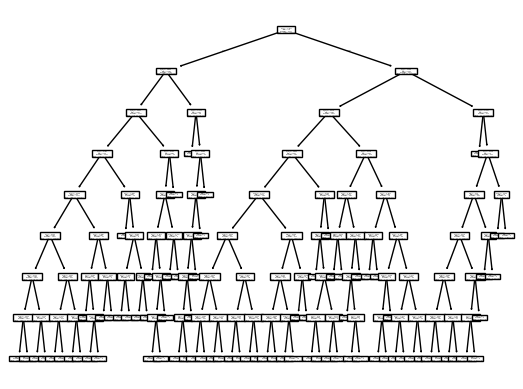

In [252]:
from sklearn import tree
tree.plot_tree(dt)

In [253]:
dt.fit(X_train_std, y_train)
train_pred = dt.predict(X_train_std)
test_pred = dt.predict(X_test_std)
from sklearn.metrics import accuracy_score
print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 0.8249051833122629
Test Accuracy: 0.7848194546794399


 4.2 Random Forest

In [254]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier( n_estimators=15, max_depth=None, min_samples_split=2, class_weight="balanced",random_state=0)

Train model

In [255]:
rfc.fit(X_train_std, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=15, random_state=0)

Predict

In [256]:
y_predict = rfc.predict(X_test_std)

In [257]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_predict))

[[1176   25]
 [ 127   29]]


In [258]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_predict))

0.887988209285188


In [259]:
from sklearn.metrics import precision_score
print(precision_score(y_test, y_predict, average='binary'))


0.5370370370370371


In [260]:
from sklearn.metrics import recall_score
print(recall_score(y_test, y_predict, average='binary'))

0.1858974358974359


In [261]:
from sklearn.metrics import f1_score
print(f1_score(y_test, y_predict, average='binary'))

0.2761904761904762


In [262]:
train_pred_rf = rfc.predict(X_train_std)
test_pred_rf = rfc.predict(X_test_std)

print("Train Accuracy:", accuracy_score(y_train, train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, test_pred_rf))

Train Accuracy: 0.9968394437420987
Test Accuracy: 0.887988209285188


# **5. Model Evaluation**

In [263]:
def evaluate_model(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

results = pd.DataFrame({
    "Decision Tree": evaluate_model(y_test, y_pred_dt),
    "Random Forest": evaluate_model(y_test, y_predict)
}).T

print("\nModel Comparison:")
print(results)


Model Comparison:
               Accuracy  Precision    Recall  F1 Score
Decision Tree  0.784819   0.316216  0.750000  0.444867
Random Forest  0.887988   0.537037  0.185897  0.276190


จากผลการเปรียบเทียบพบว่า Random Forest มีค่า Accuracy สูงสุดที่ 89% อย่างไรก็ตาม ค่า Recall สำหรับ Class 1 มีเพียง 21.5% แสดงว่าโมเดลสามารถตรวจจับลูกค้าที่สมัครจริงได้เพียงส่วนน้อย

ในขณะที่ Decision Tree มี Accuracy ต่ำกว่าเล็กน้อยที่ประมาณ 82% แต่มีค่า Recall สูงถึงประมาณ 69%  และมีค่า F1 Score สูงกว่า Random Forest แสดงให้เห็นถึงความสมดุลของโมเดลที่ดีกว่าในการตรวจจับกลุ่มลูกค้าที่สำคัญ

ดังนั้น หากเป้าหมายของงานคือ “ลดการพลาดลูกค้าที่มีแนวโน้มสมัครเงินจริง” Decision Tree จึงเหมาะสมกว่า Random Forest

# **6.Final Model**

In [264]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

final_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    class_weight="balanced",
    random_state=0
)

final_model.fit(X_train_std, y_train)

y_final = final_model.predict(X_test_std)

print("Final Model: Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_final))
print("Precision:", precision_score(y_test, y_final))
print("Recall:", recall_score(y_test, y_final))
print("F1 Score:", f1_score(y_test, y_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_final))

print("\nClassification Report:")
print(classification_report(y_test, y_final))

Final Model: Decision Tree
Accuracy: 0.7848194546794399
Precision: 0.3162162162162162
Recall: 0.75
F1 Score: 0.4448669201520912

Confusion Matrix:
[[948 253]
 [ 39 117]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.79      0.87      1201
           1       0.32      0.75      0.44       156

    accuracy                           0.78      1357
   macro avg       0.64      0.77      0.66      1357
weighted avg       0.89      0.78      0.82      1357



แม้ Random Forest จะมีค่า Accuracy สูงกว่า แต่มีค่า Recall ต่ำ ทำให้พลาดลูกค้าที่สมัครจริงจำนวนมาก

ในขณะที่ Decision Tree มีค่า Recall และ F1 Score สูงกว่า แสดงถึงความสมดุลที่ดีกว่าในการตรวจจับลูกค้าที่มีโอกาสสมัคร

ดังนั้น หากวัตถุประสงค์ทางธุรกิจต้องการลดการพลาดลูกค้า Decision Tree จึงเป็นโมเดลที่เหมาะสมที่สุดสำหรับใช้เป็น Final Model

## **7.Feature Selection**

Embedded method วิธี Decision Tree

In [266]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance)

                Feature    Importance
3              duration  5.289266e-01
40     poutcome_success  8.123313e-02
27      contact_unknown  7.247349e-02
0                   age  5.689659e-02
1               balance  3.911516e-02
2                   day  2.826555e-02
5                 pdays  2.640103e-02
34            month_mar  2.545197e-02
4              campaign  2.163568e-02
14          job_student  1.823753e-02
24          housing_yes  1.736502e-02
30            month_feb  1.577495e-02
32            month_jul  1.167029e-02
7       job_blue-collar  1.020864e-02
36            month_nov  9.793403e-03
28            month_aug  7.763368e-03
13         job_services  7.157902e-03
18      marital_married  5.699580e-03
21   education_tertiary  4.337990e-03
38            month_sep  3.965358e-03
25             loan_yes  2.169576e-03
8      job_entrepreneur  1.808831e-03
19       marital_single  1.104293e-03
26    contact_telephone  1.017425e-03
22    education_unknown  9.848743e-04
35          

จากการวิเคราะห์ Feature Importance ของโมเดล พบว่า duration มีค่า Importance สูงที่สุดประมาณ 0.53 แสดงว่าระยะเวลาในการติดต่อกับลูกค้ามีอิทธิพลอย่างมากต่อการตัดสินใจสมัคร ซึ่งหมายความว่า ยิ่งใช้เวลาในการสนทนานาน โอกาสที่ลูกค้าจะสมัครมีแนวโน้มสูงขึ้นอย่างชัดเจน

รองลงมาคือ poutcome_success (ประมาณ 0.11) ซึ่งสะท้อนว่าลูกค้าที่เคยตอบรับสำเร็จในการติดต่อครั้งก่อน มีแนวโน้มสมัครซ้ำมากกว่าลูกค้าทั่วไป

ถัดมาคือ contact_unknown (ประมาณ 0.09) และ age (ประมาณ 0.06) แสดงให้เห็นว่าวิธีการติดต่อและช่วงอายุของลูกค้ามีผลต่อพฤติกรรมการตัดสินใจเช่นกัน

ตัวแปรอื่น ๆ เช่น month_mar, campaign, day, job_blue-collar มีอิทธิพลในระดับรองลงมา

ในขณะที่หลายตัวแปรมีค่า Importance เท่ากับ 0 แสดงว่าโมเดลไม่ได้เลือกใช้ตัวแปรเหล่านั้นในการแบ่งกิ่งของต้นไม้ เนื่องจากไม่ได้ช่วยลดความไม่บริสุทธิ์ของข้อมูลอย่างมีนัยสำคัญ

แม้ duration จะมีความสำคัญสูงมาก แต่ในสถานการณ์การใช้งานจริง ตัวแปรนี้อาจไม่สามารถใช้ทำนายล่วงหน้าได้ เนื่องจากเป็นข้อมูลที่ทราบหลังจากการติดต่อเสร็จสิ้นแล้ว จึงควรพิจารณาความเหมาะสมในการนำไปใช้เชิงปฏิบัติ